# Basic data exploration *Eget læringsutbytte*

## Setup

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

MAIN_VARIABLES = [
  "laerutb_teori_13", "laerutb_metforsk_13", "laerutb_egenerf_13", "laerutb_fagspes_13",
  "laerutb_refleks_13", "laerutb_samarb_13", "laerutb_muntkom_13", "laerutb_skriftkom_13",
  "laerutb_tenke_13", "laerutb_selvst_13"
]
columns_of_interest = [
  "studiepgm_navn", "instnavn", "studiested",
  "fagfelt", "faggruppe", "utdanningsgruppe", "utd_type"
] + MAIN_VARIABLES 

# Add project root to path if needed
project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

from src.tasks.task_2_1_1.config import DATA_PATH

df = pd.read_excel(DATA_PATH / "programfil_SB2025_portal.xlsx")

## Exploration

### Check data structure

In [27]:
df_subset = df[columns_of_interest].copy()

# Check data types and missing values
df_subset.info()
print("\nMissing values:")
df_subset.isnull().sum()

# Check for value ranges for the variables
print("\nValue ranges:")
for col in MAIN_VARIABLES:
  print(f"{col}: {df_subset[col].min()} - {df_subset[col].max()}")

<class 'pandas.DataFrame'>
RangeIndex: 1945 entries, 0 to 1944
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   studiepgm_navn        1945 non-null   str    
 1   instnavn              1945 non-null   str    
 2   studiested            1945 non-null   str    
 3   fagfelt               1945 non-null   str    
 4   faggruppe             1945 non-null   str    
 5   utdanningsgruppe      1945 non-null   str    
 6   utd_type              1945 non-null   str    
 7   laerutb_teori_13      1188 non-null   float64
 8   laerutb_metforsk_13   1188 non-null   float64
 9   laerutb_egenerf_13    1188 non-null   float64
 10  laerutb_fagspes_13    1188 non-null   float64
 11  laerutb_refleks_13    1188 non-null   float64
 12  laerutb_samarb_13     1188 non-null   float64
 13  laerutb_muntkom_13    1188 non-null   float64
 14  laerutb_skriftkom_13  1188 non-null   float64
 15  laerutb_tenke_13      1188 non-n

### Summary statistics table

In [28]:
summary_stats = df_subset[MAIN_VARIABLES].describe().round(2)
summary_stats

,laerutb_teori_13,laerutb_metforsk_13,laerutb_egenerf_13,laerutb_fagspes_13,laerutb_refleks_13,laerutb_samarb_13,laerutb_muntkom_13,laerutb_skriftkom_13,laerutb_tenke_13,laerutb_selvst_13
count,1188.00,1188.00,1188.00,1188.00,1188.00,1188.00,1188.00,1188.00,1188.00,1188.00
mean,3.82,3.52,3.39,3.47,4.02,4.05,3.83,3.91,3.76,4.21
std,0.35,0.45,0.47,0.52,0.34,0.34,0.37,0.32,0.37,0.28
min,2.52,2.21,1.90,1.89,2.57,2.89,2.46,2.58,2.67,3.17
25%,3.60,3.22,3.05,3.10,3.80,3.83,3.60,3.71,3.50,4.00
50%,3.82,3.52,3.37,3.47,4.00,4.07,3.83,3.90,3.75,4.22
75%,4.05,3.82,3.71,3.82,4.25,4.29,4.09,4.11,4.00,4.40
max,4.89,5.00,4.78,4.88,5.00,5.00,5.00,4.89,5.00,5.00


### Visualization tests

#### Visualization test 1: Bar chart, mean scores

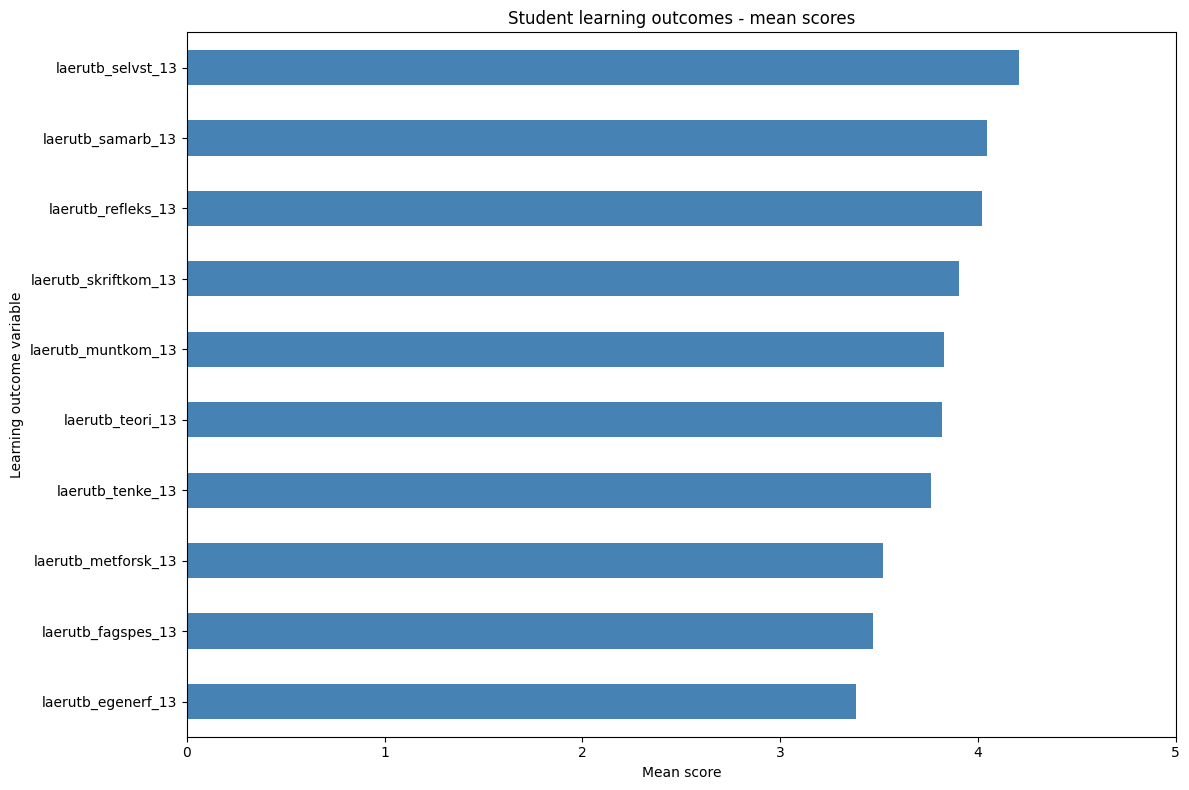

In [29]:
means = df_subset[MAIN_VARIABLES].mean().sort_values()

plt.figure(figsize=(12, 8))
means.plot(kind="barh", color="steelblue")
plt.xlabel("Mean score")
plt.ylabel("Learning outcome variable")
plt.title("Student learning outcomes - mean scores")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

#### Visualization test 2: Heatmap of correlations

FileNotFoundError: [Errno 2] No such file or directory: 'figures/laerutb_correlation.png'

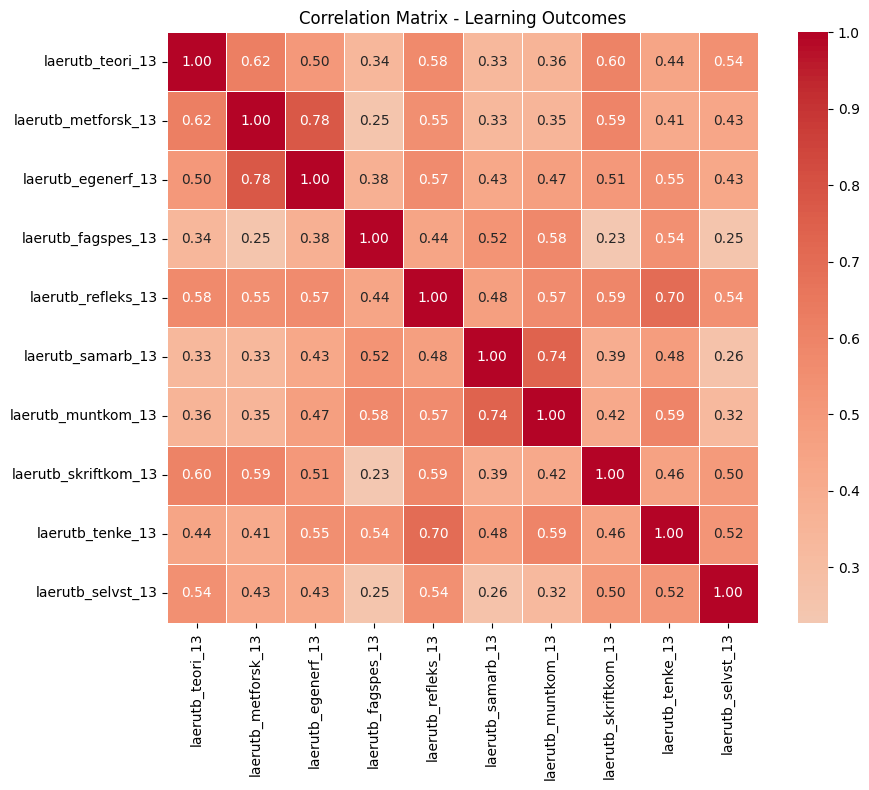

In [ ]:
# Calculate correlation matrix
corr_matrix = df_subset[MAIN_VARIABLES].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix - Learning Outcomes')
plt.tight_layout()
plt.show()